<a href="https://colab.research.google.com/github/jesusessu/MDD-LAB05/blob/develop/MDD_Lab_05_Esplana_Sulla_Jes%C3%BAs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MDD - LABORATORIO 05

Esplana Sulla Jesús Zósimo

Parte A: Lectura de Datos, Preprocesamiento y Estadísticas Descriptivas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Configuración estética para los gráficos
sns.set_theme(style="whitegrid")

In [3]:
!pip install ucimlrepo

In [4]:
from ucimlrepo import fetch_ucirepo
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)

In [5]:
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets

In [6]:
# Combinar en un DataFrame
df = pd.concat([X, y], axis=1)

In [8]:
# Visualizar las primeras filas
display(df.head(20))

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2
5,8,10,10,8,7,10.0,9,7,1,4
6,1,1,1,1,2,10.0,3,1,1,2
7,2,1,2,1,2,1.0,3,1,1,2
8,2,1,1,1,2,1.0,1,1,5,2
9,4,2,1,1,2,1.0,2,1,1,2


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
if df.isnull().sum().sum() > 0:
    print("Se encontraron valores faltantes. Se eliminarán las filas incompletas.")
    df.dropna(inplace=True)

Se encontraron valores faltantes. Se eliminarán las filas incompletas.


In [11]:
# Mostrar información y estadísticas básicas
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 449 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              449 non-null    int64  
 1   Uniformity_of_cell_size      449 non-null    int64  
 2   Uniformity_of_cell_shape     449 non-null    int64  
 3   Marginal_adhesion            449 non-null    int64  
 4   Single_epithelial_cell_size  449 non-null    int64  
 5   Bare_nuclei                  449 non-null    float64
 6   Bland_chromatin              449 non-null    int64  
 7   Normal_nucleoli              449 non-null    int64  
 8   Mitoses                      449 non-null    int64  
 9   Class                        449 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 38.6 KB


In [12]:
display(df.describe())

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
count,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000
mean,5.378619,4.222717,4.273942,3.746102,3.879733,4.806236,4.200445,3.828508,1.913140,3.051225
std,2.869029,3.251280,3.141494,3.158413,2.456544,3.880509,2.651634,3.387146,2.068909,0.999801
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,3.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,5.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,1.000000,4.000000
75%,8.000000,7.000000,7.000000,6.000000,5.000000,10.000000,7.000000,7.000000,2.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [13]:
df['Class'] = df['Class'].apply(lambda x: 0 if x == 2 else 1 if x == 4 else x)
display(df['Class'].value_counts())

,count
Class,
1,236
0,213


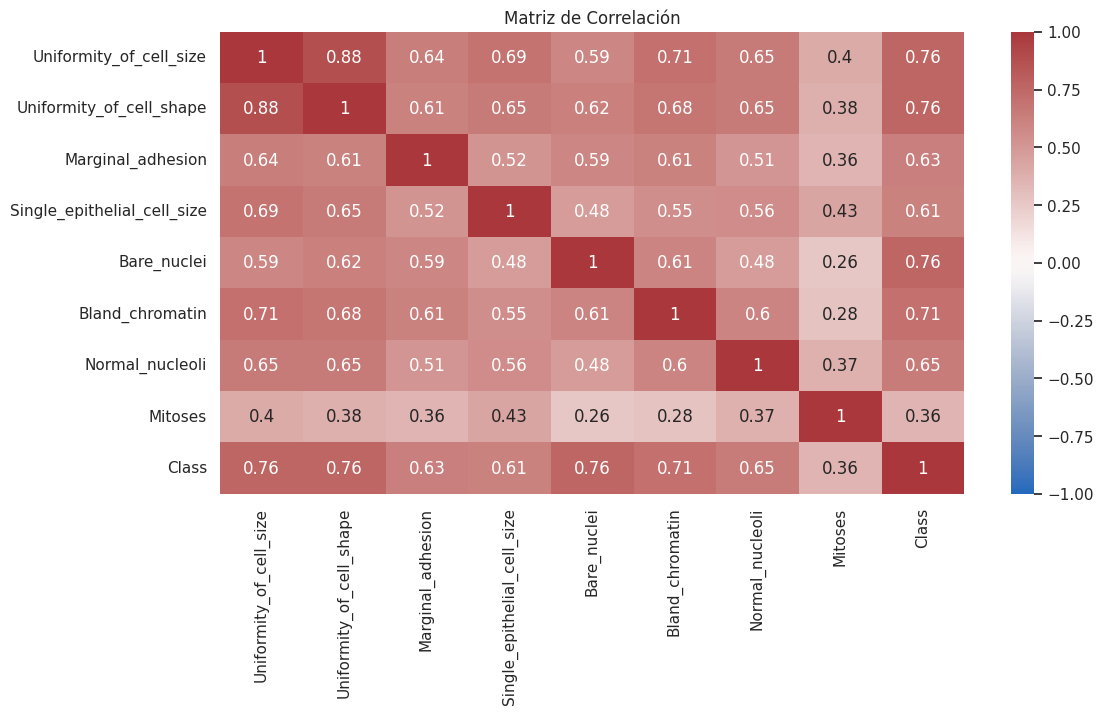

In [14]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.iloc[:, 1:].corr(), annot=True, vmin=-1, vmax=1, cmap="vlag")
plt.title('Matriz de Correlación')
plt.show()

Parte B: Visualización de Datos

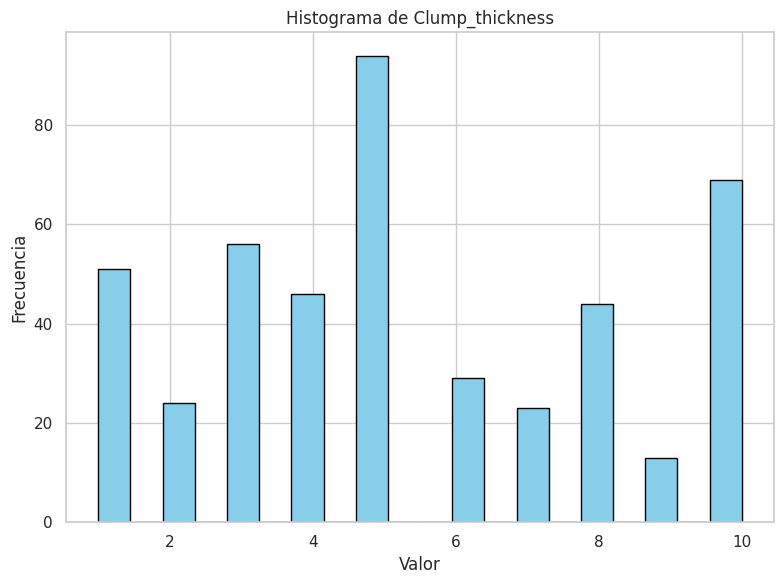

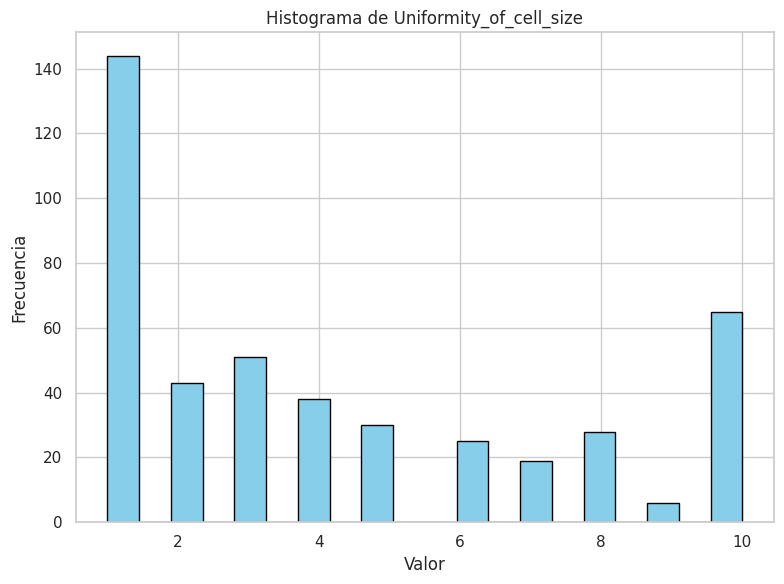

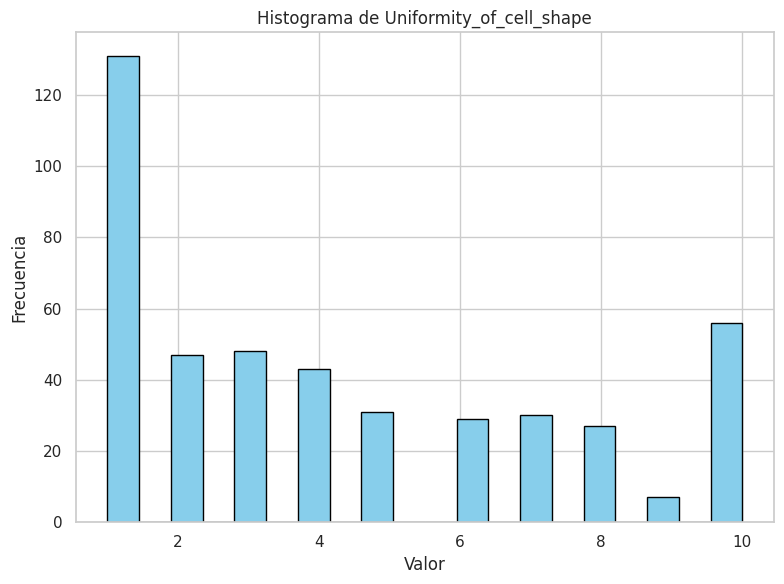

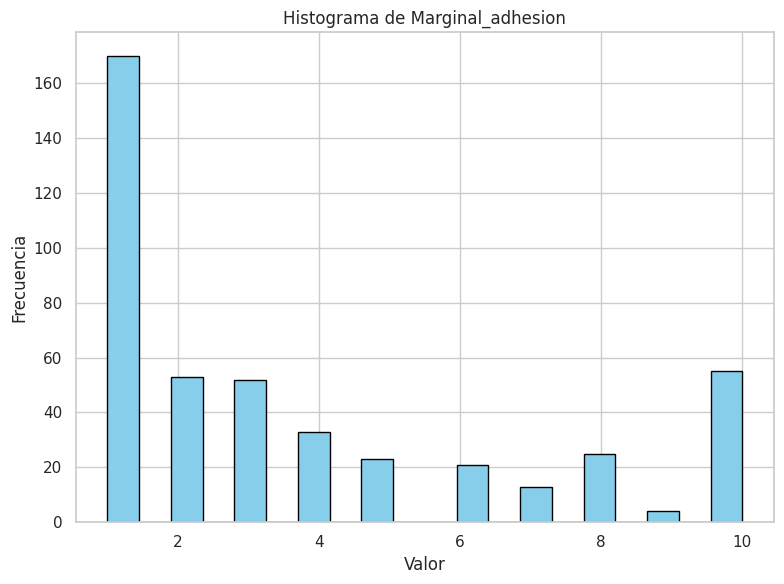

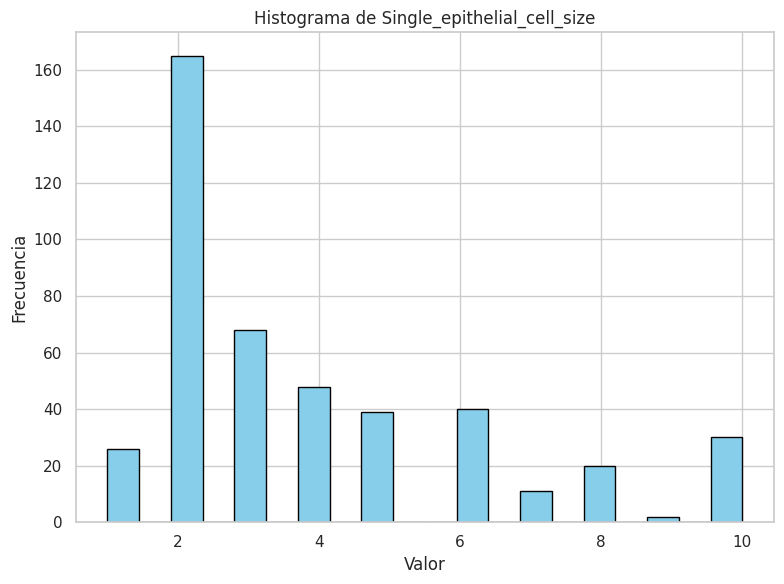

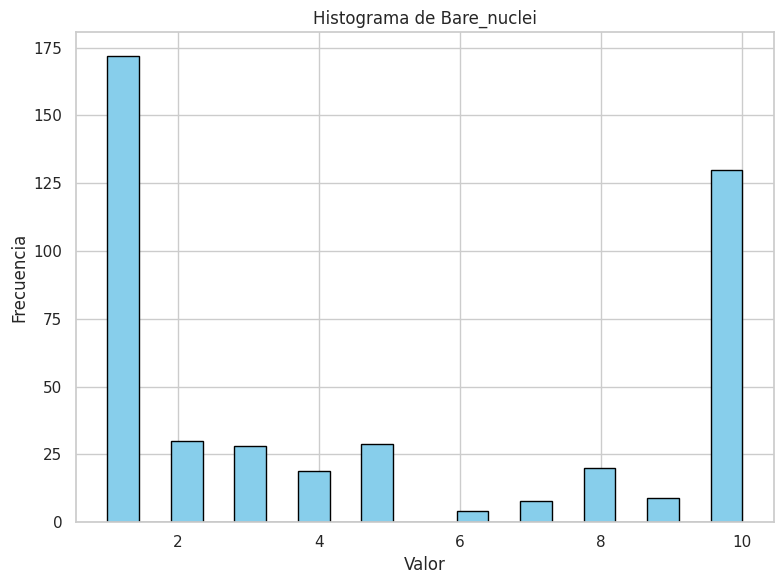

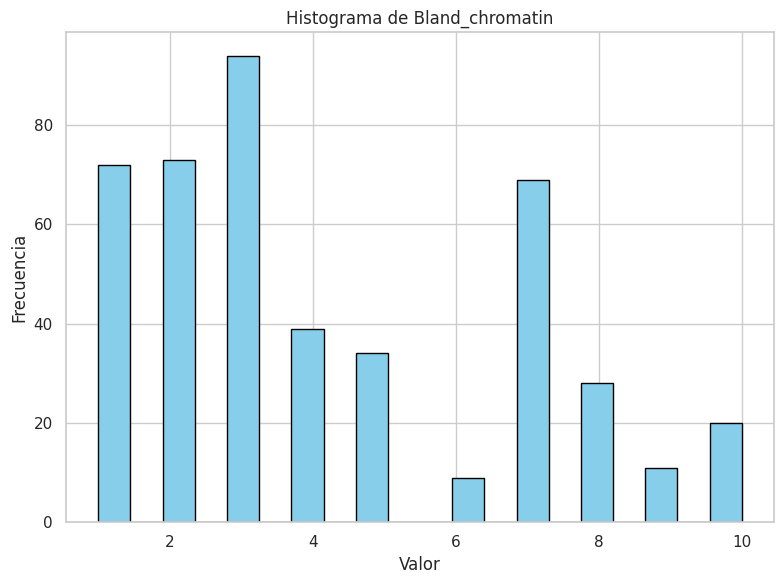

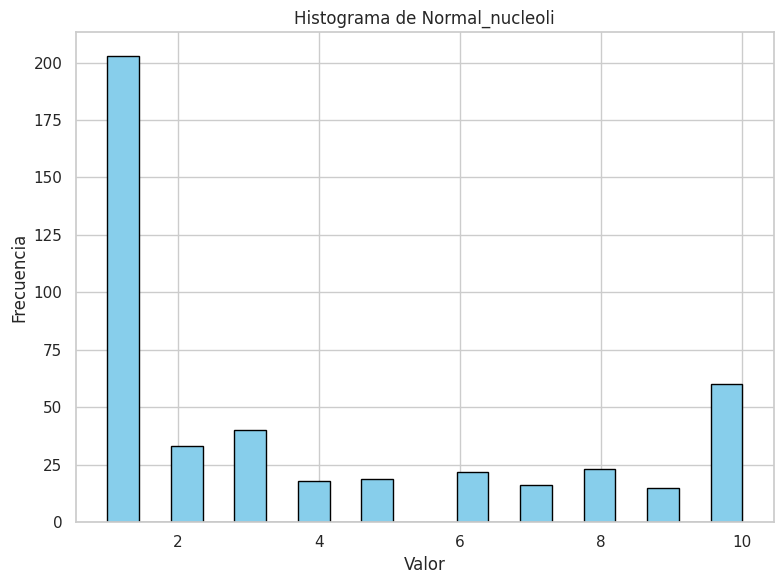

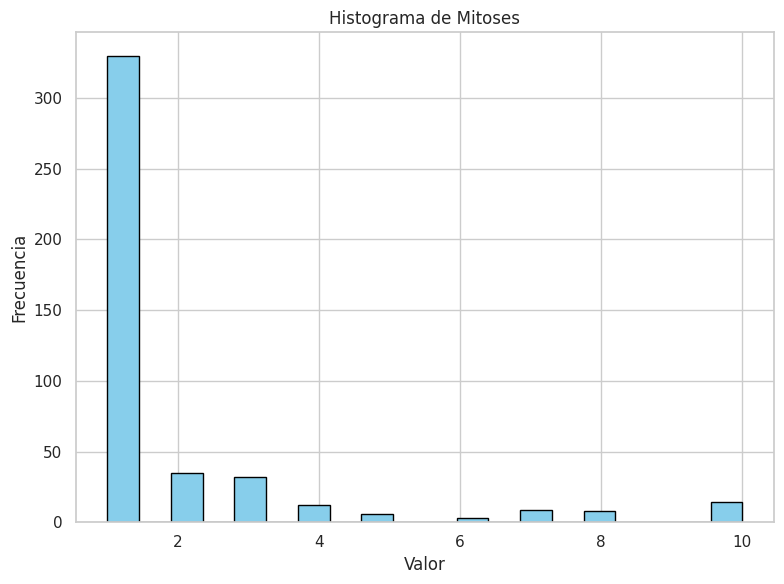

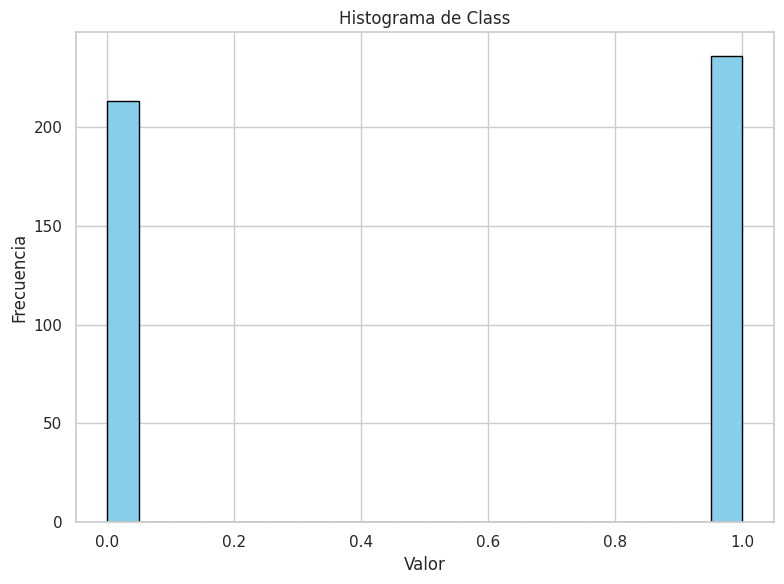

In [15]:
for col in df.columns:
    plt.figure(figsize=(8, 6))
    plt.hist(df[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Histograma de {col}')
    plt.xlabel('Valor')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

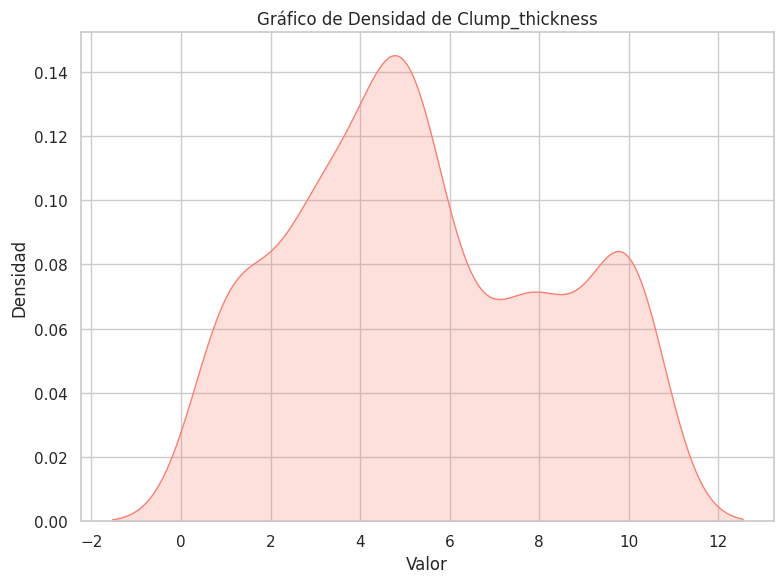

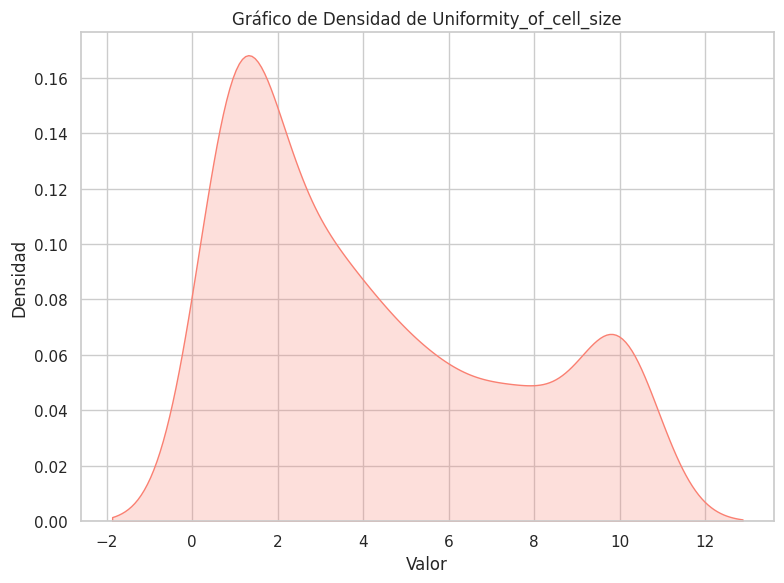

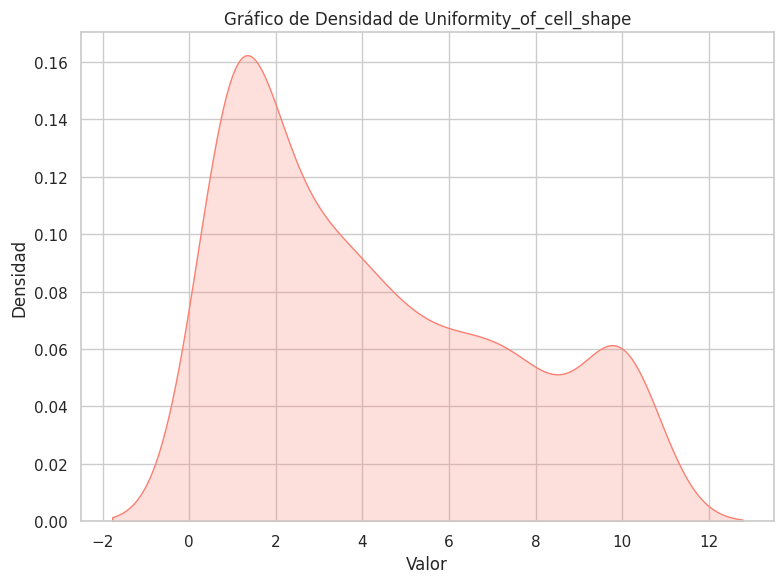

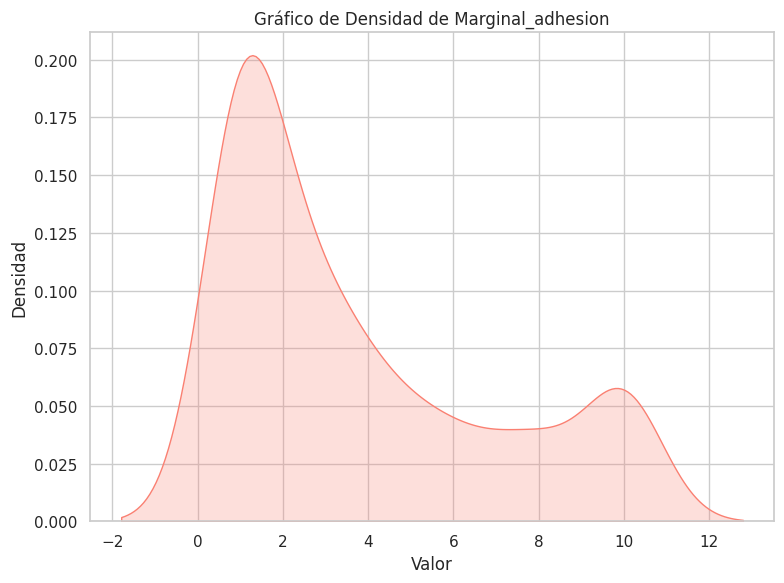

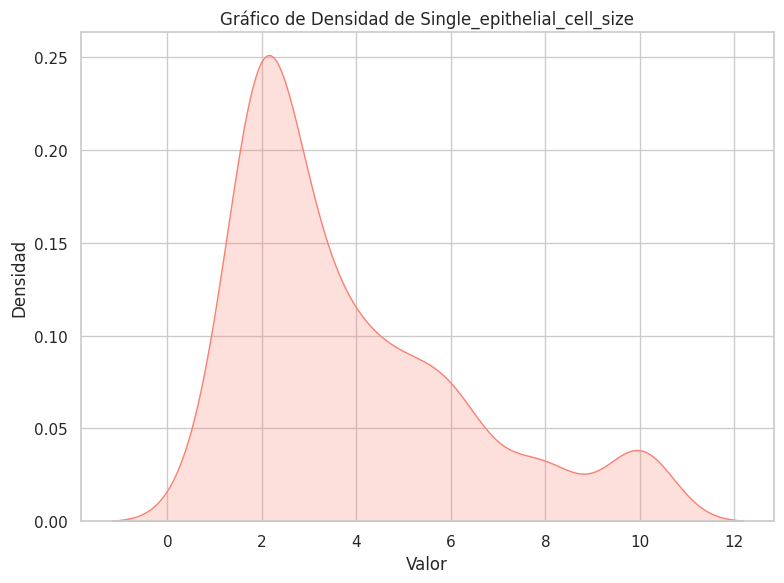

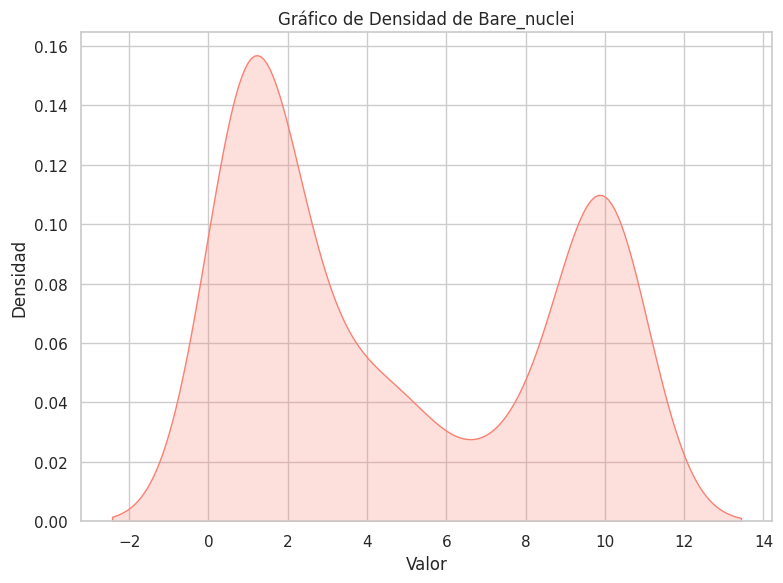

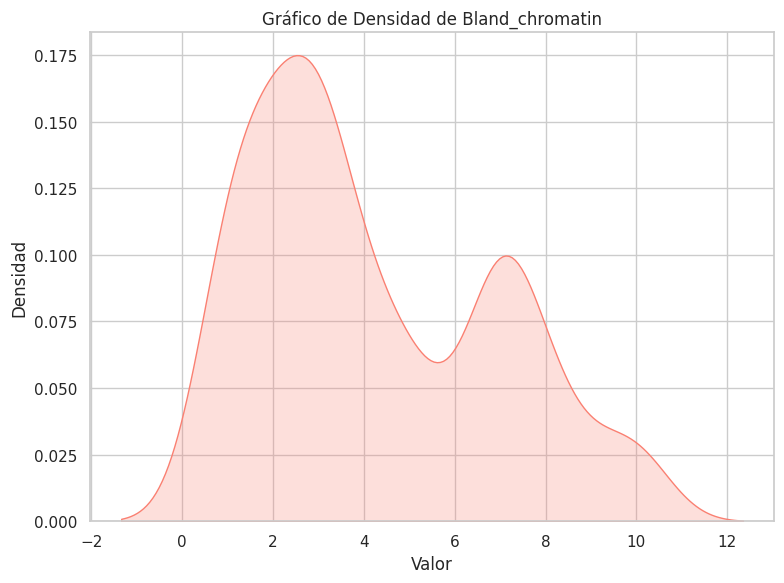

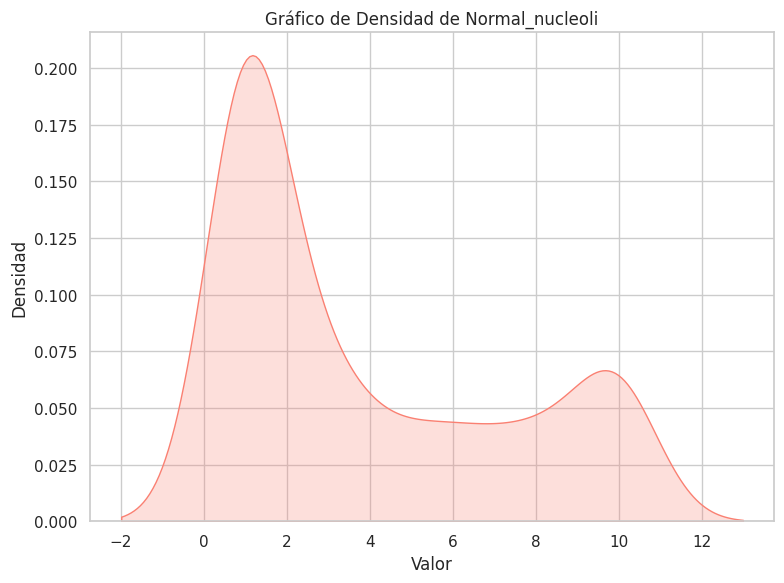

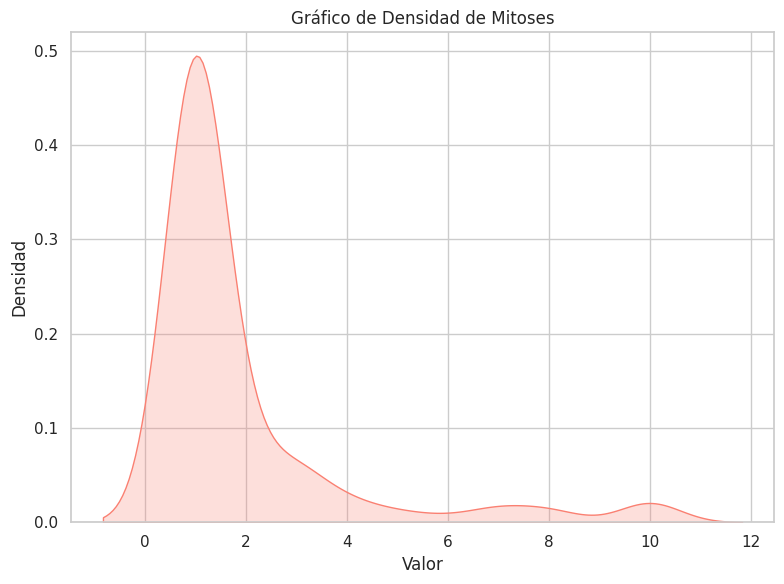

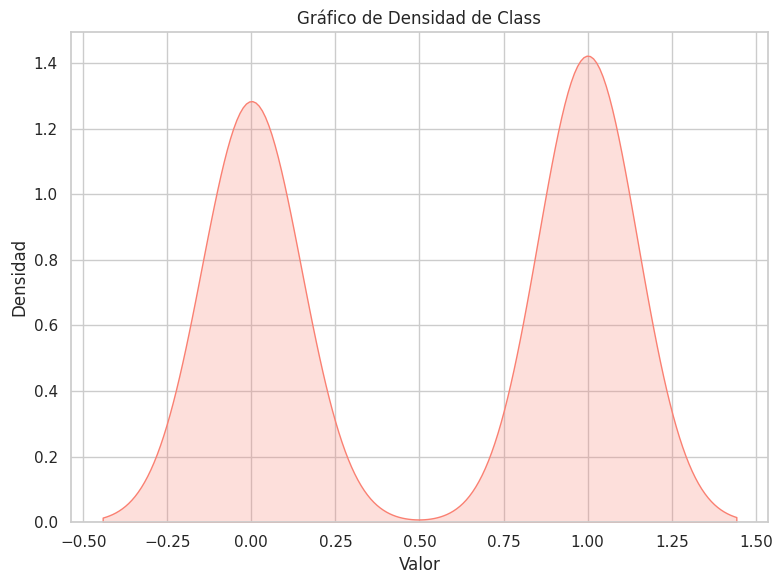

In [17]:
for col in df.columns:
    plt.figure(figsize=(8, 6))
    sns.kdeplot(data=df, x=col, color='salmon', fill=True)
    plt.title(f'Gráfico de Densidad de {col}')
    plt.xlabel('Valor')
    plt.ylabel('Densidad')
    plt.tight_layout()
    plt.show()

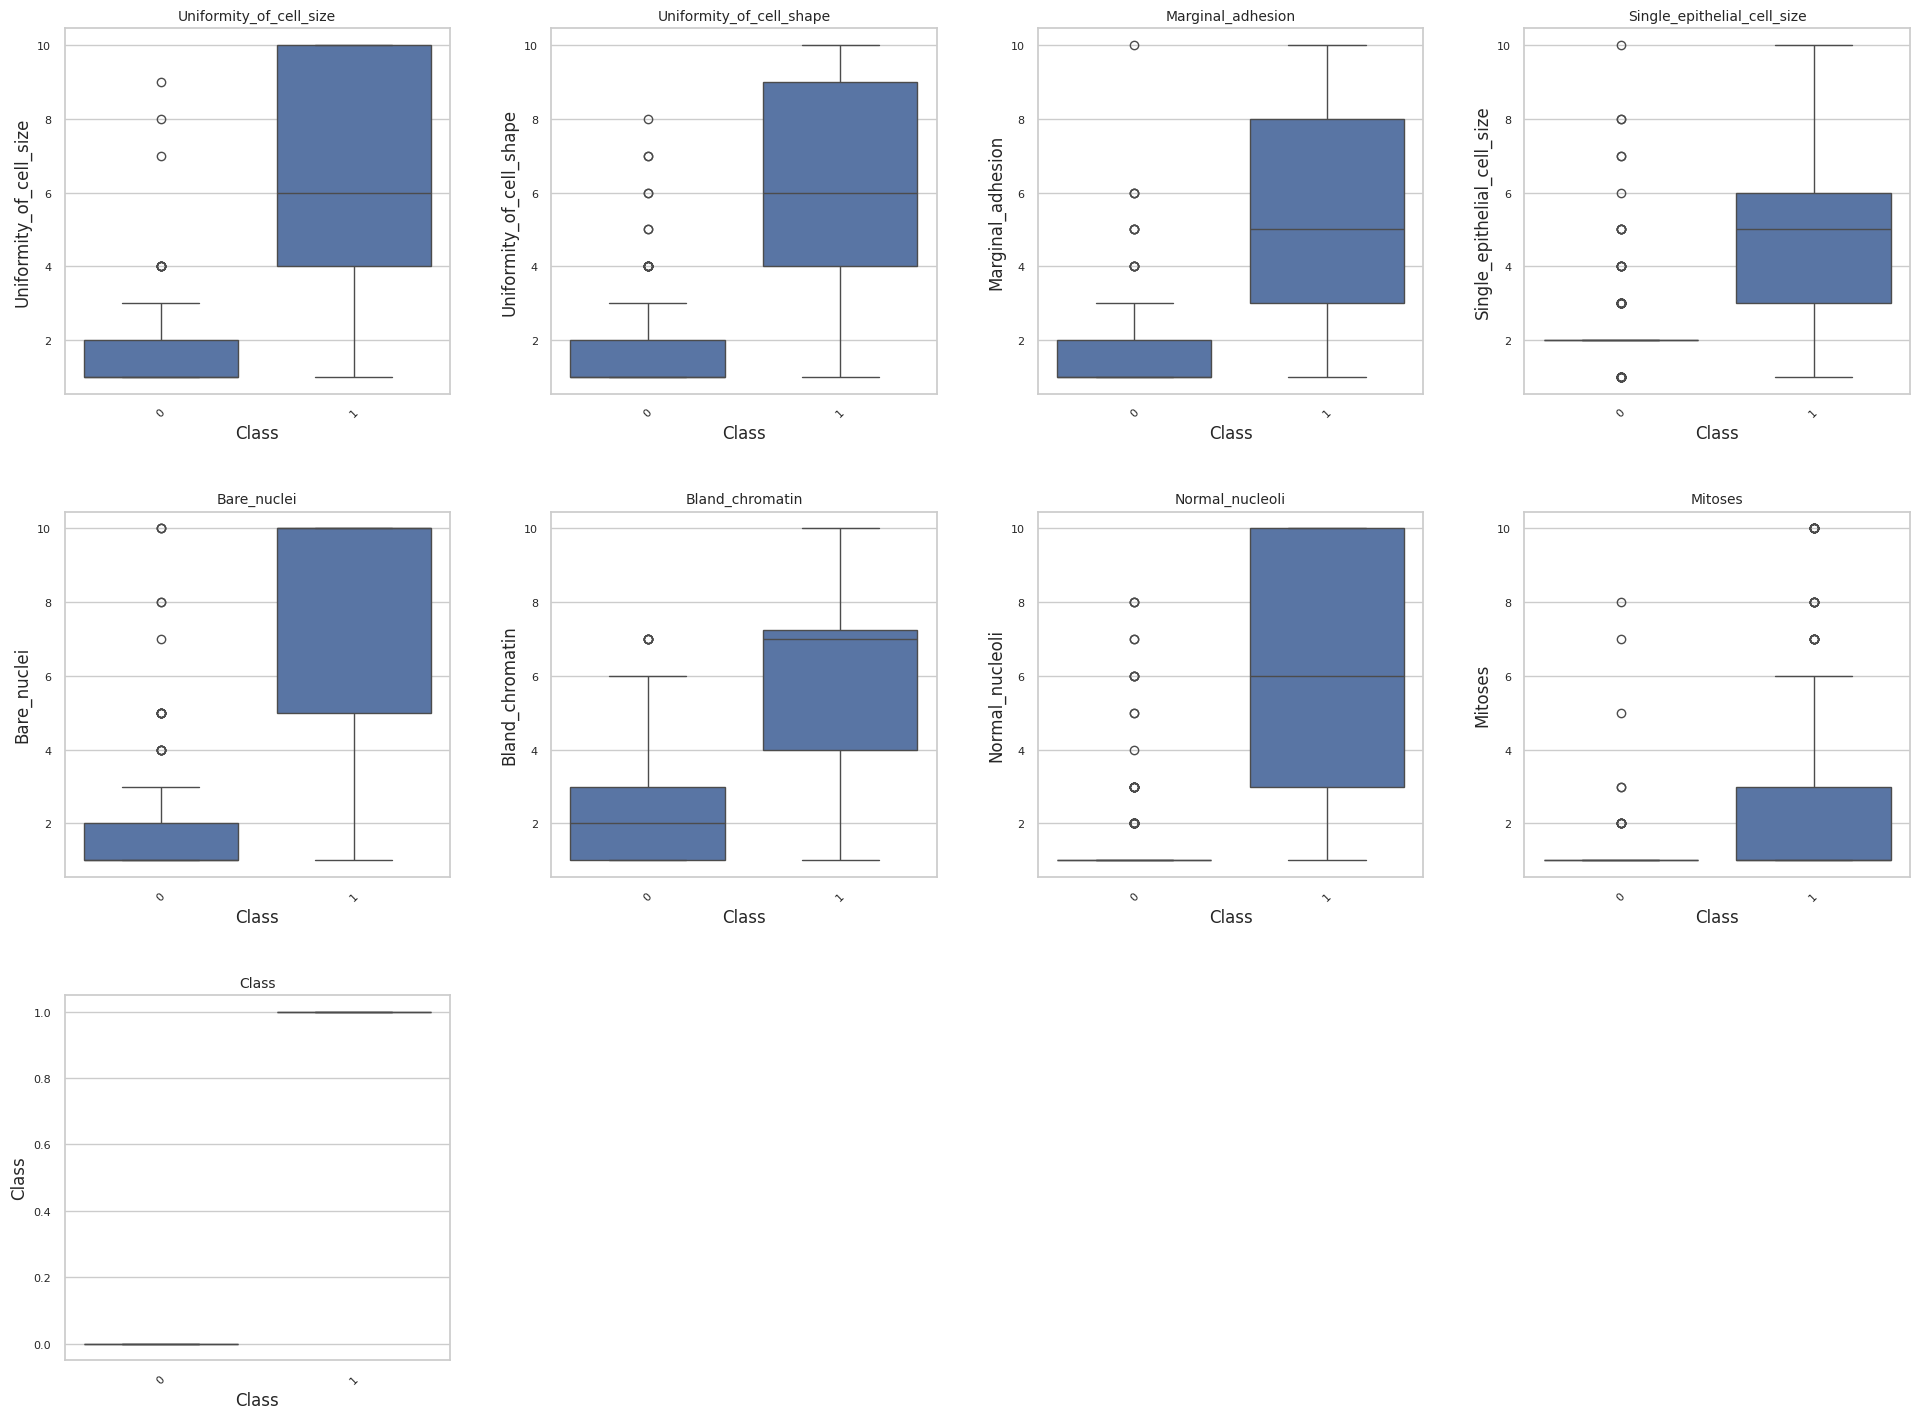

In [18]:
# Configuración de subplots para box plots
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
axes = axes.flatten()

# Asumimos que la primera columna es 'Class'. Se utilizan todas las demás.
for i, col in enumerate(df.columns[1:]):
    sns.boxplot(x='Class', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)

# Ocultar ejes sobrantes si el número total de columnas es menor a 12
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(pad=3.0)
plt.show()

Parte C: Modelado con k-NN y Evaluación

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [20]:
X = df.drop('Class', axis=1)
y = df['Class']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
knn = KNeighborsClassifier(n_neighbors=5)
# Entrenar (ajustar) el modelo usando el conjunto de entrenamiento
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [23]:
# Realizar predicciones en ambos conjuntos (entrenamiento y prueba)
y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)

# Calcular la precisión (accuracy) del modelo en ambos conjuntos
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

# resultados de la precision
print(f'Precisión en entrenamiento: {accuracy_train:.4f}')
print(f'Precisión en prueba: {accuracy_test:.4f}')

Precisión en entrenamiento: 0.9721
Precisión en prueba: 0.9667
